# PPG Power Spectral Density Analysis

`data/dataset/{split}/{case_id}.npz` 파일에서 PPG 세그먼트를 읽고 Welch PSD를 계산합니다.
또한 `power_ratio = Power(0.67–3.0 Hz) / Power(0.5–10.0 Hz)` 값을 세그먼트별 및 요약 통계로 확인합니다.

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import welch

plt.style.use('seaborn-v0_8-whitegrid')

DATASET_ROOT = Path('../data/dataset')
SPLIT = 'train'
CASE_ID = 38  # 예: '1'. None이면 선택한 split의 첫 번째 NPZ 파일을 사용합니다.
SEGMENT_INDEX = 2685
TARGET_HZ = 125

PASSBAND = (0.5, 10.0)
HEART_BAND = (0.67, 3.0)


In [14]:
def resolve_case_path(dataset_root: Path, split: str, case_id: str | None = None) -> Path:
    split_dir = dataset_root / split
    if not split_dir.exists():
        raise FileNotFoundError(f'Split directory not found: {split_dir.resolve()}')

    if case_id is not None:
        case_path = split_dir / f'{case_id}.npz'
        if not case_path.exists():
            raise FileNotFoundError(f'Case file not found: {case_path.resolve()}')
        return case_path

    case_paths = sorted(split_dir.glob('*.npz'))
    if not case_paths:
        raise FileNotFoundError(f'No NPZ files found in {split_dir.resolve()}')
    return case_paths[0]


def compute_psd(signal: np.ndarray, fs: float) -> tuple[np.ndarray, np.ndarray]:
    freqs, psd = welch(
        signal,
        fs=fs,
        window='hann',
        nperseg=min(len(signal), 256),
        noverlap=None,
        detrend='constant',
        scaling='density',
    )
    return freqs, psd


def band_power(freqs: np.ndarray, psd: np.ndarray, band: tuple[float, float]) -> float:
    lo, hi = band
    mask = (freqs >= lo) & (freqs <= hi)
    if not np.any(mask):
        return float('nan')
    return float(np.trapezoid(psd[mask], freqs[mask]))


def power_ratio_from_signal(signal: np.ndarray, fs: float) -> tuple[np.ndarray, np.ndarray, float, float, float]:
    freqs, psd = compute_psd(signal, fs)
    heart_power = band_power(freqs, psd, HEART_BAND)
    passband_power = band_power(freqs, psd, PASSBAND)
    ratio = heart_power / passband_power if passband_power > 0 else float('nan')
    return freqs, psd, heart_power, passband_power, ratio


In [15]:
case_path = resolve_case_path(DATASET_ROOT, SPLIT, CASE_ID)
case = np.load(case_path)
x = case['x']
y = case['y']

if x.ndim != 2:
    raise ValueError(f'Expected x to have shape (N, T), got {x.shape}')
if not (0 <= SEGMENT_INDEX < len(x)):
    raise IndexError(f'SEGMENT_INDEX {SEGMENT_INDEX} out of range for {len(x)} segments')

segment = x[SEGMENT_INDEX]
label = y[SEGMENT_INDEX] if len(y) > SEGMENT_INDEX else None
time_axis = np.arange(len(segment)) / TARGET_HZ

print(f'Case file      : {case_path.resolve()}')
print(f'PPG shape       : {x.shape}')
print(f'Label shape     : {y.shape}')
print(f'Selected segment: {SEGMENT_INDEX}')
if label is not None:
    print(f'SBP / DBP       : {label[0]:.2f} / {label[1]:.2f} mmHg')


Case file      : /mnt/work/doosik/bpe-vitaldb/data/dataset/train/38.npz
PPG shape       : (2686, 1000)
Label shape     : (2686, 2)
Selected segment: 2685
SBP / DBP       : 131.50 / 70.50 mmHg


In [16]:
freqs, psd, heart_power, passband_power, power_ratio = power_ratio_from_signal(segment, TARGET_HZ)

print(f'Power(0.67-3.0 Hz) : {heart_power:.6f}')
print(f'Power(0.5-10.0 Hz) : {passband_power:.6f}')
print(f'power_ratio        : {power_ratio:.6f}')


Power(0.67-3.0 Hz) : 282.829970
Power(0.5-10.0 Hz) : 353.918041
power_ratio        : 0.799140


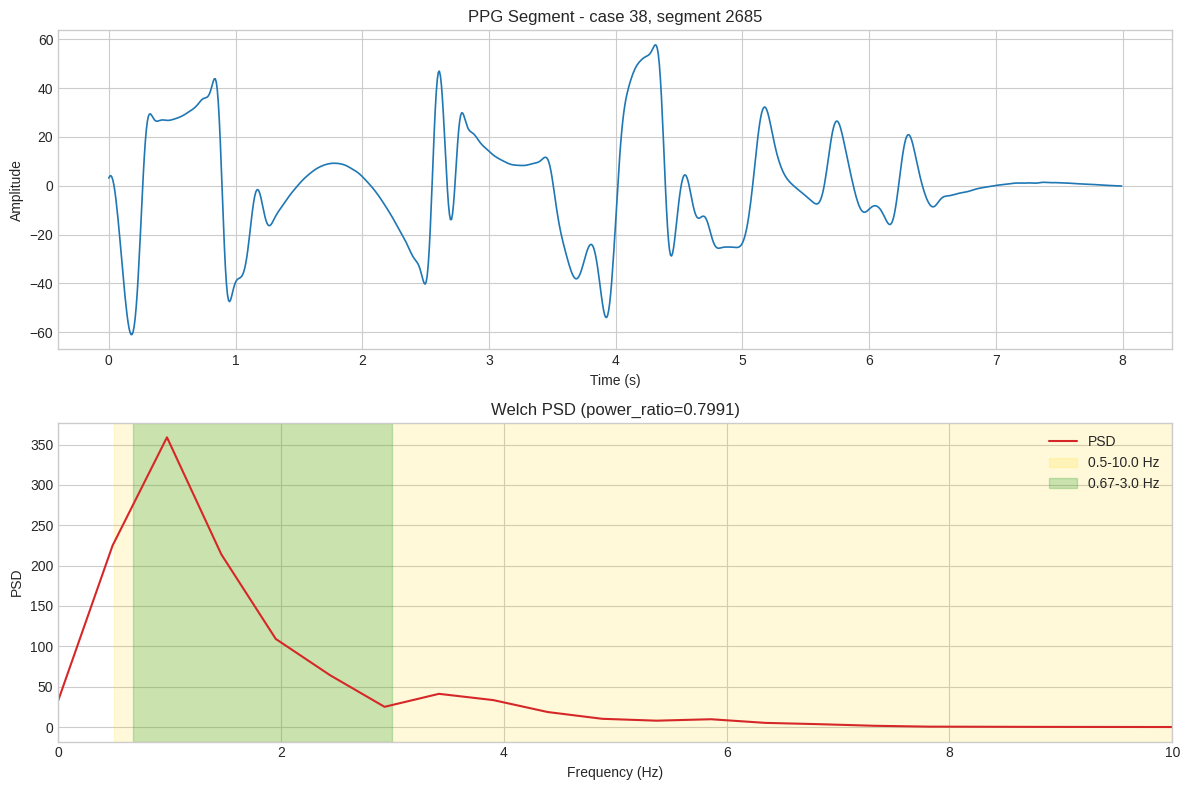

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(time_axis, segment, color='tab:blue', linewidth=1.2)
axes[0].set_title(f'PPG Segment - case {case_path.stem}, segment {SEGMENT_INDEX}')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')

axes[1].plot(freqs, psd, color='tab:red', linewidth=1.5, label='PSD')
axes[1].axvspan(*PASSBAND, color='gold', alpha=0.15, label='0.5-10.0 Hz')
axes[1].axvspan(*HEART_BAND, color='tab:green', alpha=0.25, label='0.67-3.0 Hz')
axes[1].set_xlim(0, 10)
axes[1].set_title(f'Welch PSD (power_ratio={power_ratio:.4f})')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('PSD')
axes[1].legend()

fig.tight_layout()
plt.show()


Number of segments : 2686
Mean power_ratio   : 0.804770
Median power_ratio : 0.799116
Min power_ratio    : 0.257507
Max power_ratio    : 0.997456


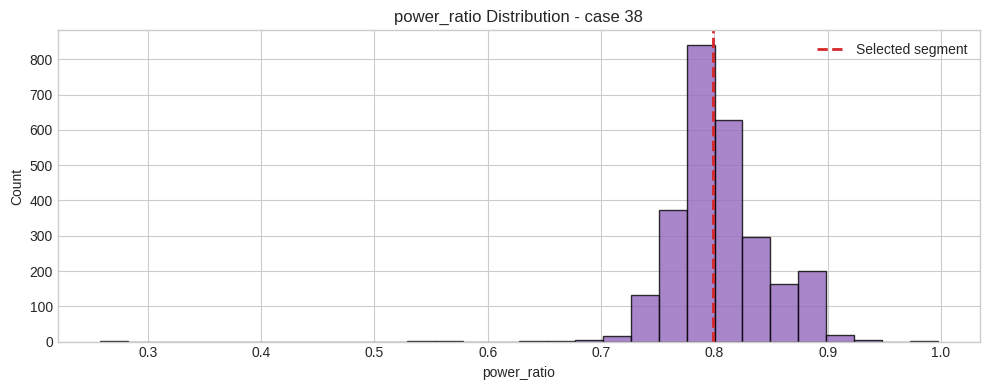

In [18]:
segment_ratios = []
for sig in x:
    _, _, _, _, ratio = power_ratio_from_signal(sig, TARGET_HZ)
    segment_ratios.append(ratio)

segment_ratios = np.asarray(segment_ratios, dtype=np.float64)

print(f'Number of segments : {len(segment_ratios)}')
print(f'Mean power_ratio   : {np.nanmean(segment_ratios):.6f}')
print(f'Median power_ratio : {np.nanmedian(segment_ratios):.6f}')
print(f'Min power_ratio    : {np.nanmin(segment_ratios):.6f}')
print(f'Max power_ratio    : {np.nanmax(segment_ratios):.6f}')

plt.figure(figsize=(10, 4))
plt.hist(segment_ratios, bins=30, color='tab:purple', alpha=0.8, edgecolor='black')
plt.axvline(power_ratio, color='tab:red', linestyle='--', linewidth=2, label='Selected segment')
plt.title(f'power_ratio Distribution - case {case_path.stem}')
plt.xlabel('power_ratio')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()
